# Smart Product Pricing Challenge - Amazon ML Challenge 2025

## Problem Overview
In e-commerce, determining the optimal price point for products is crucial for marketplace success and customer satisfaction. This challenge focuses on developing an ML solution that analyzes product details and predicts the price of products.

### Key Components:
- **catalog_content**: Text field containing title, product description and Item Pack Quantity (IPQ)
- **image_link**: Product image URLs for visual feature extraction
- **price**: Target variable (available only in training data)

### Evaluation Metric: SMAPE
Symmetric Mean Absolute Percentage Error:
```
SMAPE = (1/n) * Σ |predicted_price - actual_price| / ((|actual_price| + |predicted_price|)/2)
```

### Dataset:
- Training: 75,000 products with prices
- Test: 75,000 products for prediction

# 1. Data Loading and Exploration

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import re
import sys
from pathlib import Path
from collections import Counter
import pickle

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Image processing
import torch
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import cv2

# Other utilities
from tqdm import tqdm
import json
from datetime import datetime

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully!")
print(f"Current working directory: {os.getcwd()}")

# Download NLTK data if needed
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK data...")
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

All libraries imported successfully!
Current working directory: c:\Users\harpr\OneDrive\Desktop\AMAZON_ML_CHALLENGE_2025


In [3]:
# Define paths and create directories
DATASET_PATH = "68e8d1d70b66d_student_resource/student_resource/dataset/"
DATA_PATH = "data/"
MODELS_PATH = "models/"
IMAGES_PATH = "images/"

# Create necessary directories
for path in [DATA_PATH, MODELS_PATH, IMAGES_PATH]:
    os.makedirs(path, exist_ok=True)
    print(f"Created/verified directory: {path}")

# Define SMAPE metric function
def calculate_smape(y_true, y_pred):
    """Calculate Symmetric Mean Absolute Percentage Error"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Avoid division by zero
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = np.mean(np.abs(y_true - y_pred) / denominator) * 100
    return smape

print("Setup completed successfully!")

Created/verified directory: data/
Created/verified directory: models/
Created/verified directory: images/
Setup completed successfully!


In [4]:
# Load datasets
print("Loading datasets...")

# Load training data
train_df = pd.read_csv(os.path.join(DATASET_PATH, "train.csv"))
print(f"Training data shape: {train_df.shape}")

# Load test data
test_df = pd.read_csv(os.path.join(DATASET_PATH, "test.csv"))
print(f"Test data shape: {test_df.shape}")

# Load sample data for reference
sample_test_df = pd.read_csv(os.path.join(DATASET_PATH, "sample_test.csv"))
sample_out_df = pd.read_csv(os.path.join(DATASET_PATH, "sample_test_out.csv"))
print(f"Sample test shape: {sample_test_df.shape}")
print(f"Sample output shape: {sample_out_df.shape}")

print("\nData loading completed!")

Loading datasets...
Training data shape: (75000, 4)
Training data shape: (75000, 4)
Test data shape: (75000, 3)
Sample test shape: (100, 3)
Sample output shape: (100, 2)

Data loading completed!
Test data shape: (75000, 3)
Sample test shape: (100, 3)
Sample output shape: (100, 2)

Data loading completed!


In [5]:
# Basic data exploration
print("=== TRAINING DATA INFO ===")
print(train_df.info())
print("\n=== TRAINING DATA SAMPLE ===")
print(train_df.head())

print("\n=== MISSING VALUES ===")
print("Training data missing values:")
print(train_df.isnull().sum())
print("\nTest data missing values:")
print(test_df.isnull().sum())

print("\n=== COLUMN DETAILS ===")
print("Training columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

=== TRAINING DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB
None

=== TRAINING DATA SAMPLE ===
   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   
2     261251  Item Name: Bear Creek Hearty Soup Bowl, Creamy...   
3      55858  Item Name: Judee’s Blue Cheese Powder 11.25 oz...   
4     292686  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...   

                                          image_link  price  
0  https://m.media-amazon.c

=== PRICE ANALYSIS ===
Price statistics:
count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64

Price range: $0.13 - $2796.00
Price median: $14.00
Price mean: $23.65


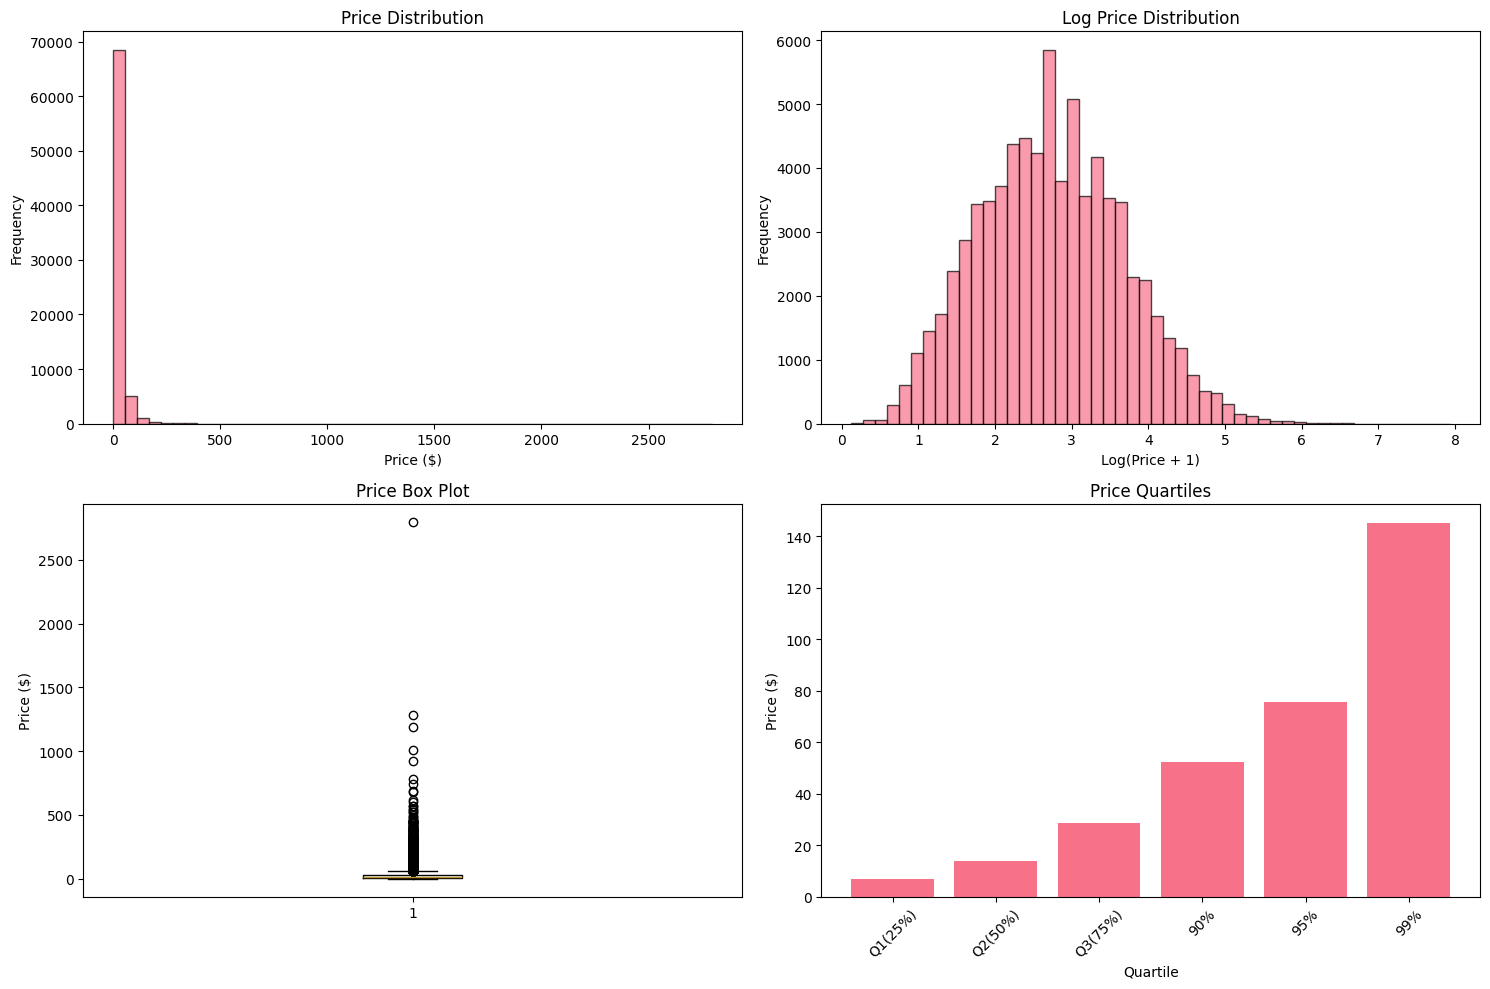


Outliers (using IQR method): 5524 (7.37%)
Outlier price range: $61.39 - $2796.00


In [6]:
# Price distribution analysis
print("=== PRICE ANALYSIS ===")
print(f"Price statistics:")
print(train_df['price'].describe())

print(f"\nPrice range: ${train_df['price'].min():.2f} - ${train_df['price'].max():.2f}")
print(f"Price median: ${train_df['price'].median():.2f}")
print(f"Price mean: ${train_df['price'].mean():.2f}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price distribution histogram
axes[0, 0].hist(train_df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')

# Log price distribution
axes[0, 1].hist(np.log1p(train_df['price']), bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Log Price Distribution')
axes[0, 1].set_xlabel('Log(Price + 1)')
axes[0, 1].set_ylabel('Frequency')

# Price box plot
axes[1, 0].boxplot(train_df['price'])
axes[1, 0].set_title('Price Box Plot')
axes[1, 0].set_ylabel('Price ($)')

# Price quartiles
quartiles = train_df['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
axes[1, 1].bar(range(len(quartiles)), quartiles.values)
axes[1, 1].set_title('Price Quartiles')
axes[1, 1].set_xlabel('Quartile')
axes[1, 1].set_ylabel('Price ($)')
axes[1, 1].set_xticks(range(len(quartiles)))
axes[1, 1].set_xticklabels(['Q1(25%)', 'Q2(50%)', 'Q3(75%)', '90%', '95%', '99%'], rotation=45)

plt.tight_layout()
plt.show()

# Identify outliers
Q1 = train_df['price'].quantile(0.25)
Q3 = train_df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['price'] < lower_bound) | (train_df['price'] > upper_bound)]
print(f"\nOutliers (using IQR method): {len(outliers)} ({len(outliers)/len(train_df)*100:.2f}%)")
print(f"Outlier price range: ${outliers['price'].min():.2f} - ${outliers['price'].max():.2f}")

# 2. Text Preprocessing and Feature Engineering

=== CATALOG CONTENT ANALYSIS ===
Sample catalog content:
Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Value: 72.0
Unit: Fl Oz
...

Text length statistics:
count    75000.000000
mean       908.886547
std        852.896151
min         32.000000
25%        251.000000
50%        643.000000
75%       1280.000000
max       7894.000000
Name: text_length, dtype: float64

Word count statistics:
count    75000.000000
mean       147.851693
std        137.068731
min          7.000000
25%         42.000000
50%        104.000000
75%        208.000000
max       1333.000000
Name: word_count, dtype: float64


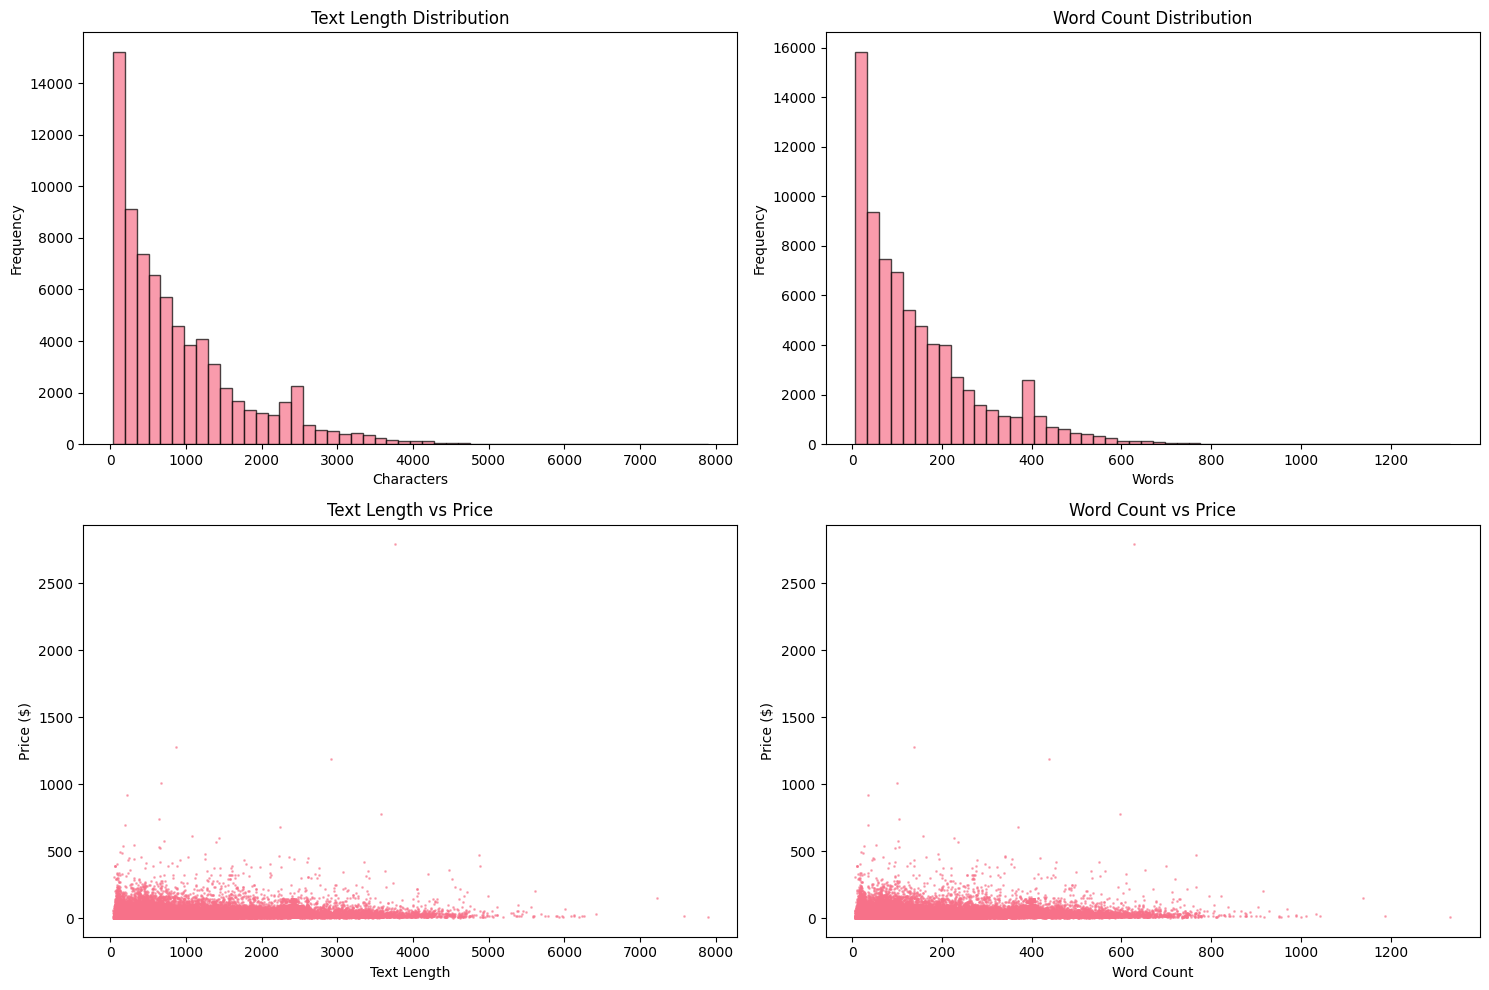


Correlation between text length and price: 0.1468
Correlation between word count and price: 0.1444


In [7]:
# Text analysis of catalog_content
print("=== CATALOG CONTENT ANALYSIS ===")
# Sample catalog content
sample_content = train_df['catalog_content'].iloc[0]
print(f"Sample catalog content:\n{sample_content[:500]}...\n")

# Basic text statistics
train_df['text_length'] = train_df['catalog_content'].str.len()
train_df['word_count'] = train_df['catalog_content'].str.split().str.len()

print("Text length statistics:")
print(train_df['text_length'].describe())
print("\nWord count statistics:")
print(train_df['word_count'].describe())

# Plot text characteristics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length distribution
axes[0, 0].hist(train_df['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Text Length Distribution')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')

# Word count distribution
axes[0, 1].hist(train_df['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Word Count Distribution')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')

# Text length vs price
axes[1, 0].scatter(train_df['text_length'], train_df['price'], alpha=0.5, s=1)
axes[1, 0].set_title('Text Length vs Price')
axes[1, 0].set_xlabel('Text Length')
axes[1, 0].set_ylabel('Price ($)')

# Word count vs price
axes[1, 1].scatter(train_df['word_count'], train_df['price'], alpha=0.5, s=1)
axes[1, 1].set_title('Word Count vs Price')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# Correlations
print(f"\nCorrelation between text length and price: {train_df['text_length'].corr(train_df['price']):.4f}")
print(f"Correlation between word count and price: {train_df['word_count'].corr(train_df['price']):.4f}")

In [8]:
# Extract structured information from catalog_content
def extract_text_features(text):
    """Extract structured features from catalog content"""
    features = {}
    
    # Extract item name
    name_match = re.search(r'Item Name:\s*([^\n]*)', text)
    features['item_name'] = name_match.group(1).strip() if name_match else ""
    
    # Extract value and unit
    value_match = re.search(r'Value:\s*([0-9.]+)', text)
    features['value'] = float(value_match.group(1)) if value_match else 0.0
    
    unit_match = re.search(r'Unit:\s*([^\n]*)', text)
    features['unit'] = unit_match.group(1).strip() if unit_match else ""
    
    # Count bullet points
    features['bullet_count'] = len(re.findall(r'Bullet Point \d+:', text))
    
    # Extract product description length
    desc_match = re.search(r'Product Description:\s*(.*)', text, re.DOTALL)
    features['description_length'] = len(desc_match.group(1).strip()) if desc_match else 0
    
    # Extract brand information (first word of item name)
    if features['item_name']:
        features['brand'] = features['item_name'].split()[0] if features['item_name'].split() else ""
    else:
        features['brand'] = ""
    
    # Text quality indicators
    features['has_description'] = 1 if 'Product Description:' in text else 0
    features['has_bullets'] = 1 if 'Bullet Point' in text else 0
    features['has_value'] = 1 if value_match else 0
    features['has_unit'] = 1 if unit_match else 0
    
    return features

# Apply feature extraction
print("Extracting text features...")
text_features = train_df['catalog_content'].apply(extract_text_features)
text_features_df = pd.DataFrame(text_features.tolist())

# Combine with original data
train_features = pd.concat([train_df, text_features_df], axis=1)

print("Extracted features:")
print(text_features_df.head())
print("\nText feature statistics:")
print(text_features_df.describe())

Extracting text features...
Extracted features:
                                           item_name  value   unit  \
0  La Victoria Green Taco Sauce Mild, 12 Ounce (P...  72.00  Fl Oz   
1  Salerno Cookies, The Original Butter Cookies, ...  32.00  Ounce   
2  Bear Creek Hearty Soup Bowl, Creamy Chicken wi...  11.40  Ounce   
3  Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...  11.25  Ounce   
4  kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...  12.00  Count   

   bullet_count  description_length    brand  has_description  has_bullets  \
0             0                   0       La                0            0   
1             5                   0  Salerno                0            1   
2             5                   0     Bear                0            1   
3             5                 534  Judee’s                1            1   
4             0                   0    kedem                0            1   

   has_value  has_unit  
0          1         1  
1          1